<a href="https://colab.research.google.com/github/SANGHATI23/neurofhir-qc/blob/main/22_NeuroFHIR_TRACE_Publication_Robustness_Calibration_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NeuroFHIR-TRACE — Notebook 22
## Publication-Ready Robustness, Calibration, Statistical Testing, and Subgroup Analysis
  
**Project:** NeuroFHIR-TRACE — Provenance-Aware Reliability Gating for Longitudinal Neuroimaging AI

---

## Purpose

Notebook 21 established the downstream causal chain:

**clinical baseline → raw imaging AI → technical shift → TRACE-aware mitigation**

Notebook 22 converts those results into publication-ready statistical evidence.

### Primary goals

1. quantify clean-to-shift degradation for Models A/B/C;
2. generate calibration curves and calibration slope/intercept;
3. compare Brier score and calibration error;
4. quantify ranking stability and top-risk-set consistency;
5. test false-progression / false-change consequences;
6. compute paired subject-level bootstrap confidence intervals;
7. perform subgroup analysis by TRACE state and, where available, site/scanner;
8. create final manuscript-ready tables and figures.

### Interpretation principle

The strongest TRACE claim is not necessarily:

> “TRACE increases AUROC.”

The stronger systems claim can be:

> “TRACE reduces the downstream propagation of technically unstable neuroimaging evidence, improving calibration, prediction stability, false-change control, or robustness under shift.”

If only DEMO_MODE inputs are available, all outputs remain pipeline-validation evidence only.


In [1]:

# ============================================================
# 0. SETUP
# ============================================================

!pip -q install pandas numpy scipy scikit-learn statsmodels pyarrow matplotlib

from pathlib import Path
import json, math, random, warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, kendalltau
import statsmodels.api as sm

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

ROOT = Path("/content/neurofhir_trace")
IN21 = ROOT / "outputs_21"
OUT_DIR = ROOT / "outputs_22"
FIG_DIR = OUT_DIR / "figures"

for p in [OUT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

N_BOOT = 1000

print("Input:", IN21)
print("Output:", OUT_DIR)


Input: /content/neurofhir_trace/outputs_21
Output: /content/neurofhir_trace/outputs_22



# 1. Load Notebook 21 outputs

Preferred files:

```text
outputs_21/
├── heldout_abc_predictions.csv
├── abc_clean_shift_metrics.csv
├── abc_primary_comparisons.csv
├── abc_probability_shift.csv
├── abc_confidently_wrong.csv
├── abc_false_change_consequence.csv
├── abc_paired_bootstrap.parquet
└── ichi_trace_21_summary.csv
```

If Notebook 21 outputs are missing because Colab started a new runtime, this notebook creates a compact DEMO fallback with the same schema so all publication-analysis code still runs.


In [2]:

# ============================================================
# 1. LOAD NOTEBOOK 21 OUTPUTS
# ============================================================

pred_path = IN21 / "heldout_abc_predictions.csv"
metrics_path = IN21 / "abc_clean_shift_metrics.csv"

DEMO_MODE = not (pred_path.exists() and metrics_path.exists())

if not DEMO_MODE:
    pred = pd.read_csv(pred_path)
    results21 = pd.read_csv(metrics_path)

    print("Loaded Notebook 21 outputs.")
    print("Prediction rows:", len(pred))

else:
    print("Notebook 21 outputs not found.")
    print("Creating a compact DEMO fallback.")
    print("IMPORTANT: outputs remain pipeline-validation only.")


Notebook 21 outputs not found.
Creating a compact DEMO fallback.
IMPORTANT: outputs remain pipeline-validation only.



# 2. DEMO fallback

This fallback recreates the same qualitative causal structure as Notebook 21:

- Model A is stable because it contains no imaging;
- Model B gains clean-data signal but becomes more fragile under technical shift;
- C1/C2/C3 attenuate unstable imaging evidence;
- C2/C3 generally preserve calibration/ranking better under shift.

The fallback is only for testing the Notebook 22 analysis pipeline.


In [3]:

# ============================================================
# 2. DEMO DATA IF NEEDED
# ============================================================

if DEMO_MODE:
    rng = np.random.default_rng(SEED)
    n = 180

    subject_id = [f"T{i:04d}" for i in range(n)]
    outcome = rng.binomial(1, 0.42, n)

    latent = rng.normal(
        0.9*outcome - 0.3*(1-outcome),
        1.0,
        n
    )

    instability = rng.binomial(1, 0.30, n)

    trace_risk = np.clip(
        rng.normal(0.15 + 0.65*instability, 0.14),
        0, 1
    )

    trace_state = np.where(
        trace_risk <= 0.25,
        "TRUSTED",
        np.where(
            trace_risk >= 0.65,
            "REVIEW_REQUIRED",
            "CAUTION"
        )
    )

    def sigmoid(z):
        return 1/(1+np.exp(-z))

    a_clean = sigmoid(
        -0.5 + 0.8*latent + rng.normal(0,0.35,n)
    )
    a_shift = a_clean.copy()

    b_clean = sigmoid(
        -0.45 + 1.0*latent + rng.normal(0,0.22,n)
    )

    shift_error = rng.normal(
        0,
        0.25 + 1.0*instability,
        n
    )

    b_shift = np.clip(
        b_clean + 0.18*shift_error,
        0.001, 0.999
    )

    c1_shift = np.where(
        trace_state=="TRUSTED",
        b_shift,
        a_clean
    )
    c1_clean = np.where(
        trace_state=="TRUSTED",
        b_clean,
        a_clean
    )

    reliability = 1-trace_risk
    c2_clean = np.clip(
        a_clean + reliability*(b_clean-a_clean),
        0.001, 0.999
    )
    c2_shift = np.clip(
        a_clean + reliability*(b_shift-a_clean),
        0.001, 0.999
    )

    state_weight = np.where(
        trace_state=="TRUSTED",
        1.0,
        np.where(
            trace_state=="CAUTION",
            reliability,
            0.0
        )
    )

    c3_clean = np.clip(
        a_clean + state_weight*(b_clean-a_clean),
        0.001, 0.999
    )
    c3_shift = np.clip(
        a_clean + state_weight*(b_shift-a_clean),
        0.001, 0.999
    )

    false_change_event = (
        np.abs(b_shift-b_clean) >= 0.15
    ).astype(int)

    site = rng.choice(
        ["SITE_A","SITE_B","SITE_C"],
        n,
        p=[0.45,0.35,0.20]
    )

    scanner = rng.choice(
        ["3T_A","3T_B"],
        n
    )

    pred = pd.DataFrame({
        "subject_id": subject_id,
        "outcome": outcome,
        "trace_state": trace_state,
        "trace_risk": trace_risk,
        "false_change_event": false_change_event,
        "site": site,
        "scanner": scanner,
        "A_clinical_clean": a_clean,
        "A_clinical_shifted": a_shift,
        "B_raw_imaging_clean": b_clean,
        "B_raw_imaging_shifted": b_shift,
        "C1_trusted_only_clean": c1_clean,
        "C1_trusted_only_shifted": c1_shift,
        "C2_reliability_weighted_clean": c2_clean,
        "C2_reliability_weighted_shifted": c2_shift,
        "C3_full_TRACE_clean": c3_clean,
        "C3_full_TRACE_shifted": c3_shift,
    })

print("DEMO_MODE =", DEMO_MODE)
print("Rows:", len(pred))
display(pred.head())


DEMO_MODE = True
Rows: 180


,subject_id,outcome,trace_state,trace_risk,false_change_event,site,scanner,A_clinical_clean,A_clinical_shifted,B_raw_imaging_clean,B_raw_imaging_shifted,C1_trusted_only_clean,C1_trusted_only_shifted,C2_reliability_weighted_clean,C2_reliability_weighted_shifted,C3_full_TRACE_clean,C3_full_TRACE_shifted
0,T0000,1,TRUSTED,0.099352,0,SITE_B,3T_B,0.584972,0.584972,0.605091,0.596231,0.605091,0.596231,0.603092,0.595113,0.605091,0.596231
1,T0001,0,TRUSTED,0.018243,0,SITE_B,3T_B,0.356789,0.356789,0.270648,0.220490,0.270648,0.220490,0.272219,0.222976,0.270648,0.220490
2,T0002,1,TRUSTED,0.087201,0,SITE_B,3T_B,0.521582,0.521582,0.656104,0.645786,0.656104,0.645786,0.644374,0.634955,0.656104,0.645786
3,T0003,1,TRUSTED,0.213327,0,SITE_B,3T_A,0.779125,0.779125,0.853771,0.782095,0.853771,0.782095,0.837847,0.781462,0.853771,0.782095
4,T0004,0,TRUSTED,0.000000,0,SITE_B,3T_B,0.345646,0.345646,0.354526,0.313447,0.354526,0.313447,0.354526,0.313447,0.354526,0.313447



# 3. Model list and helpers


In [4]:

# ============================================================
# 3. MODEL DEFINITIONS
# ============================================================

MODELS = [
    "A_clinical",
    "B_raw_imaging",
    "C1_trusted_only",
    "C2_reliability_weighted",
    "C3_full_TRACE"
]

STATE_ORDER = [
    "TRUSTED",
    "CAUTION",
    "REVIEW_REQUIRED"
]



# 4. Core metric functions


In [5]:

# ============================================================
# 4. METRICS
# ============================================================

def expected_calibration_error(y, p, n_bins=10):
    y = np.asarray(y)
    p = np.asarray(p)

    bins = np.linspace(0,1,n_bins+1)
    ids = np.digitize(
        p,
        bins[1:-1],
        right=True
    )

    ece = 0.0

    for b in range(n_bins):
        m = ids==b
        if not np.any(m):
            continue

        ece += (
            np.mean(m)
            * abs(
                np.mean(y[m])
                - np.mean(p[m])
            )
        )

    return float(ece)


def safe_auroc(y,p):
    return (
        roc_auc_score(y,p)
        if len(np.unique(y))==2
        else np.nan
    )


def safe_auprc(y,p):
    return (
        average_precision_score(y,p)
        if len(np.unique(y))==2
        else np.nan
    )


def calibration_slope_intercept(y,p):
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    eps = 1e-6
    p = np.clip(p,eps,1-eps)
    logit = np.log(p/(1-p))

    X = sm.add_constant(logit)

    try:
        fit = sm.Logit(y,X).fit(disp=0)
        intercept = float(fit.params[0])
        slope = float(fit.params[1])
    except Exception:
        intercept = np.nan
        slope = np.nan

    return intercept,slope


def rank_metrics(clean_p, shifted_p):
    clean_p = np.asarray(clean_p)
    shifted_p = np.asarray(shifted_p)

    s = spearmanr(clean_p,shifted_p).statistic
    k = kendalltau(clean_p,shifted_p).statistic

    n_top = max(
        1,
        int(round(len(clean_p)*0.20))
    )

    top_clean = set(np.argsort(clean_p)[-n_top:])
    top_shift = set(np.argsort(shifted_p)[-n_top:])

    consistency = (
        len(top_clean.intersection(top_shift))
        / n_top
    )

    return s,k,consistency



# 5. Publication-ready clean vs shifted metric table

This table is designed to become a Results table directly.

For each model:

- AUROC
- AUPRC
- Brier
- ECE
- calibration intercept
- calibration slope
- clean→shift degradation
- ranking stability


In [6]:

# ============================================================
# 5. MASTER METRIC TABLE
# ============================================================

y = pred["outcome"].values

rows = []

for model in MODELS:

    pc = pred[f"{model}_clean"].values
    ps = pred[f"{model}_shifted"].values

    ci_c, cs_c = calibration_slope_intercept(y,pc)
    ci_s, cs_s = calibration_slope_intercept(y,ps)

    s,k,topc = rank_metrics(pc,ps)

    row = {
        "model": model,

        "clean_AUROC": safe_auroc(y,pc),
        "shifted_AUROC": safe_auroc(y,ps),

        "clean_AUPRC": safe_auprc(y,pc),
        "shifted_AUPRC": safe_auprc(y,ps),

        "clean_Brier": brier_score_loss(y,pc),
        "shifted_Brier": brier_score_loss(y,ps),

        "clean_ECE": expected_calibration_error(y,pc),
        "shifted_ECE": expected_calibration_error(y,ps),

        "clean_calibration_intercept": ci_c,
        "shifted_calibration_intercept": ci_s,

        "clean_calibration_slope": cs_c,
        "shifted_calibration_slope": cs_s,

        "Spearman_clean_vs_shift": s,
        "Kendall_clean_vs_shift": k,
        "Top20pct_consistency": topc
    }

    row["AUROC_degradation"] = (
        row["clean_AUROC"]
        - row["shifted_AUROC"]
    )

    row["Brier_worsening"] = (
        row["shifted_Brier"]
        - row["clean_Brier"]
    )

    row["ECE_worsening"] = (
        row["shifted_ECE"]
        - row["clean_ECE"]
    )

    rows.append(row)

master = pd.DataFrame(rows)

display(
    master[
        [
            "model",
            "clean_AUROC",
            "shifted_AUROC",
            "AUROC_degradation",
            "clean_Brier",
            "shifted_Brier",
            "Brier_worsening",
            "shifted_ECE",
            "shifted_calibration_slope",
            "Spearman_clean_vs_shift",
            "Top20pct_consistency"
        ]
    ]
)


,model,clean_AUROC,shifted_AUROC,AUROC_degradation,clean_Brier,shifted_Brier,Brier_worsening,shifted_ECE,shifted_calibration_slope,Spearman_clean_vs_shift,Top20pct_consistency
0,A_clinical,0.744335,0.744335,0.000000,0.201421,0.201421,0.000000,0.082051,1.088949,1.000000,1.000000
1,B_raw_imaging,0.753937,0.735373,0.018564,0.199166,0.212600,0.013434,0.083556,0.405978,0.874330,0.750000
2,C1_trusted_only,0.757265,0.766995,-0.009730,0.196155,0.194155,-0.002000,0.073302,1.064269,0.989619,0.972222
3,C2_reliability_weighted,0.753297,0.752913,0.000384,0.197882,0.197908,0.000026,0.070466,1.042331,0.980886,0.861111
4,C3_full_TRACE,0.755089,0.759954,-0.004865,0.197364,0.196739,-0.000625,0.065555,1.018583,0.985043,0.888889



# 6. Calibration curves

The calibration figure is especially important if TRACE improves reliability without a large AUROC gain.


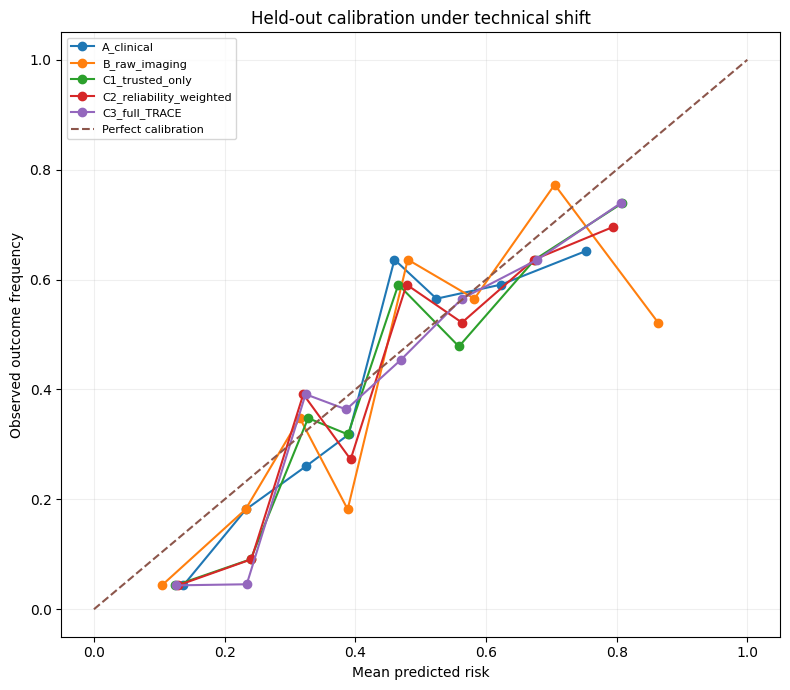

In [7]:

# ============================================================
# 6. CALIBRATION CURVES — SHIFTED CONDITION
# ============================================================

fig, ax = plt.subplots(figsize=(8,7))

for model in MODELS:
    p = pred[f"{model}_shifted"].values

    frac_pos, mean_pred = calibration_curve(
        y,
        p,
        n_bins=8,
        strategy="quantile"
    )

    ax.plot(
        mean_pred,
        frac_pos,
        marker="o",
        label=model
    )

ax.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Perfect calibration"
)

ax.set_xlabel("Mean predicted risk")
ax.set_ylabel("Observed outcome frequency")
ax.set_title("Held-out calibration under technical shift")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIG_DIR/"shifted_calibration_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 7. Clean-vs-shift degradation figure


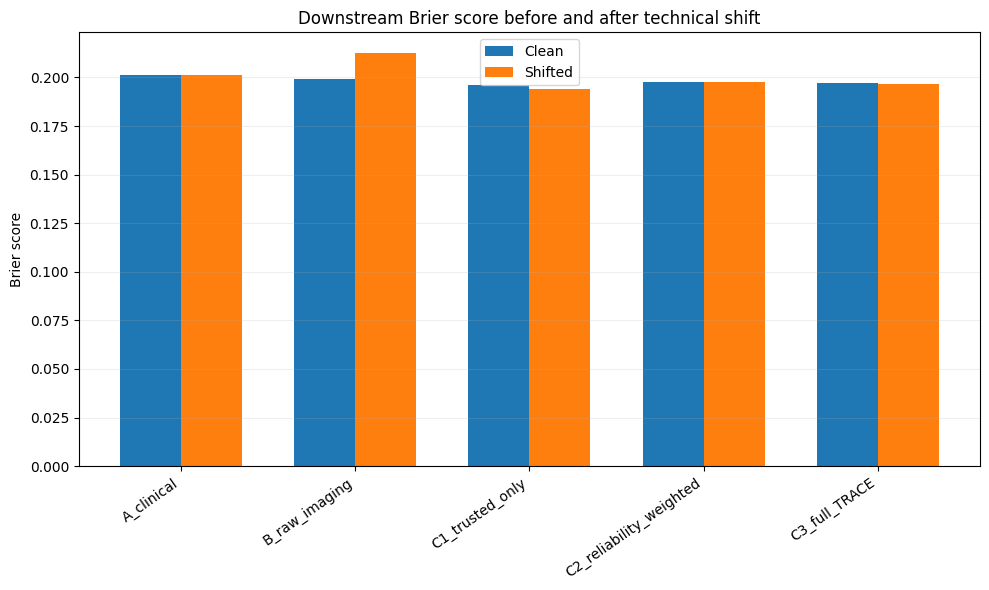

In [8]:

# ============================================================
# 7. BRIER DEGRADATION FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(len(master))
width = 0.35

ax.bar(
    x-width/2,
    master["clean_Brier"],
    width,
    label="Clean"
)

ax.bar(
    x+width/2,
    master["shifted_Brier"],
    width,
    label="Shifted"
)

ax.set_xticks(x)
ax.set_xticklabels(
    master["model"],
    rotation=35,
    ha="right"
)

ax.set_ylabel("Brier score")
ax.set_title("Downstream Brier score before and after technical shift")
ax.legend()
ax.grid(axis="y",alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIG_DIR/"clean_shift_brier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 8. Ranking stability figure


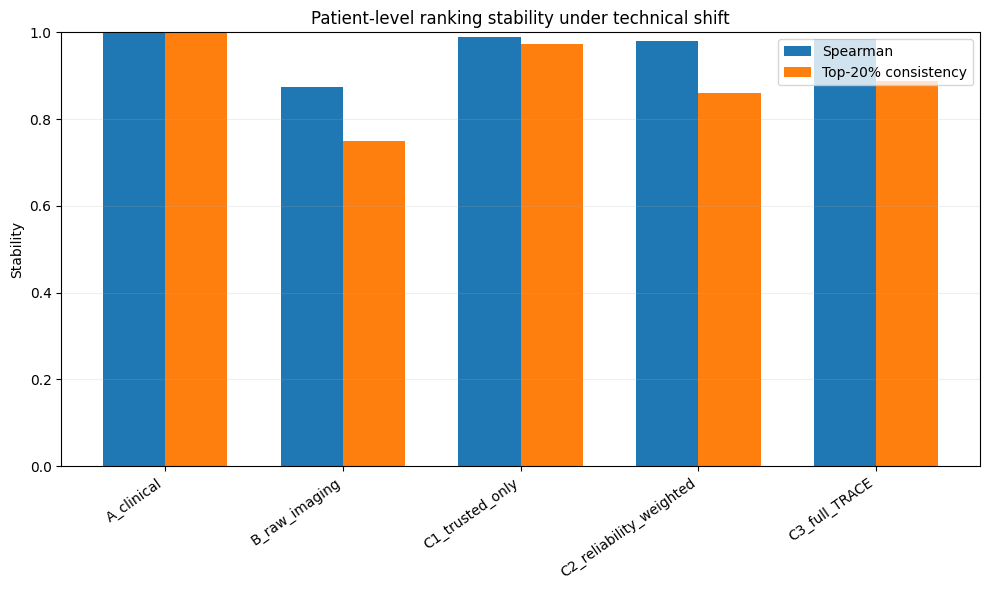

In [9]:

# ============================================================
# 8. RANKING STABILITY
# ============================================================

fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(len(master))
width = 0.35

ax.bar(
    x-width/2,
    master["Spearman_clean_vs_shift"],
    width,
    label="Spearman"
)

ax.bar(
    x+width/2,
    master["Top20pct_consistency"],
    width,
    label="Top-20% consistency"
)

ax.set_xticks(x)
ax.set_xticklabels(
    master["model"],
    rotation=35,
    ha="right"
)

ax.set_ylim(0,1)
ax.set_ylabel("Stability")
ax.set_title("Patient-level ranking stability under technical shift")
ax.legend()
ax.grid(axis="y",alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIG_DIR/"ranking_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 9. False-change / false-progression consequence

If a technical perturbation triggers an apparent imaging change, quantify how much downstream risk changes.

Primary endpoint:

**absolute downstream probability shift**


In [10]:

# ============================================================
# 9. FALSE-CHANGE CONSEQUENCE
# ============================================================

false_change_table = pd.DataFrame()

if "false_change_event" in pred.columns:

    rows = []

    fc = pred["false_change_event"].fillna(0).astype(int).values

    for model in MODELS:
        pc = pred[f"{model}_clean"].values
        ps = pred[f"{model}_shifted"].values

        delta = np.abs(ps-pc)

        rows.append({
            "model": model,
            "mean_abs_probability_shift_all": float(delta.mean()),
            "mean_abs_probability_shift_false_change": (
                float(delta[fc==1].mean())
                if np.any(fc==1) else np.nan
            ),
            "mean_abs_probability_shift_no_false_change": (
                float(delta[fc==0].mean())
                if np.any(fc==0) else np.nan
            ),
            "large_shift_rate_false_change": (
                float((delta[fc==1] >= 0.15).mean())
                if np.any(fc==1) else np.nan
            ),
            "large_shift_rate_no_false_change": (
                float((delta[fc==0] >= 0.15).mean())
                if np.any(fc==0) else np.nan
            )
        })

    false_change_table = pd.DataFrame(rows)

    display(false_change_table)
else:
    print("No false_change_event column available.")


,model,mean_abs_probability_shift_all,mean_abs_probability_shift_false_change,mean_abs_probability_shift_no_false_change,large_shift_rate_false_change,large_shift_rate_no_false_change
0,A_clinical,0.000000,0.000000,0.000000,0.0,0.0
1,B_raw_imaging,0.078144,0.273632,0.043646,1.0,0.0
2,C1_trusted_only,0.019095,0.000000,0.022464,0.0,0.0
3,C2_reliability_weighted,0.032143,0.057124,0.027734,0.0,0.0
4,C3_full_TRACE,0.026189,0.017319,0.027754,0.0,0.0



# 10. TRACE-state subgroup analysis

This asks whether raw imaging fragility is concentrated where TRACE says the evidence is less reliable.

Expected pattern:

- TRUSTED: B and TRACE-aware models should behave similarly;
- CAUTION: some attenuation benefit may appear;
- REVIEW_REQUIRED: raw B should show the greatest prediction instability.


In [11]:

# ============================================================
# 10. TRACE STATE SUBGROUP ANALYSIS
# ============================================================

state_rows = []

if "trace_state" in pred.columns:

    for state in STATE_ORDER:
        g = pred[pred.trace_state==state].copy()

        if len(g) < 5:
            continue

        for model in MODELS:
            pc = g[f"{model}_clean"].values
            ps = g[f"{model}_shifted"].values
            yg = g["outcome"].values

            state_rows.append({
                "trace_state": state,
                "model": model,
                "n": len(g),
                "mean_abs_probability_shift": float(np.mean(np.abs(ps-pc))),
                "clean_Brier": brier_score_loss(yg,pc),
                "shifted_Brier": brier_score_loss(yg,ps),
                "Brier_worsening": (
                    brier_score_loss(yg,ps)
                    - brier_score_loss(yg,pc)
                ),
                "clean_AUROC": safe_auroc(yg,pc),
                "shifted_AUROC": safe_auroc(yg,ps)
            })

state_table = pd.DataFrame(state_rows)

display(state_table.head(20))


,trace_state,model,n,mean_abs_probability_shift,clean_Brier,shifted_Brier,Brier_worsening,clean_AUROC,shifted_AUROC
0,TRUSTED,A_clinical,104,0.000000,0.199287,0.199287,0.000000,0.755179,0.755179
1,TRUSTED,B_raw_imaging,104,0.033048,0.190172,0.186711,-0.003461,0.775141,0.787571
2,TRUSTED,C1_trusted_only,104,0.033048,0.190172,0.186711,-0.003461,0.775141,0.787571
3,TRUSTED,C2_reliability_weighted,104,0.029448,0.191329,0.188003,-0.003326,0.772881,0.783804
4,TRUSTED,C3_full_TRACE,104,0.033048,0.190172,0.186711,-0.003461,0.775141,0.787571
5,CAUTION,A_clinical,30,0.000000,0.183067,0.183067,0.000000,0.805000,0.805000
6,CAUTION,B_raw_imaging,30,0.082639,0.202247,0.236625,0.034378,0.740000,0.670000
7,CAUTION,C1_trusted_only,30,0.000000,0.183067,0.183067,0.000000,0.805000,0.805000
8,CAUTION,C2_reliability_weighted,30,0.042566,0.190320,0.198569,0.008249,0.775000,0.750000
9,CAUTION,C3_full_TRACE,30,0.042566,0.190320,0.198569,0.008249,0.775000,0.750000



# 11. Site/scanner subgroup analysis

Run this only when site/scanner labels exist.

This analysis is secondary because small subgroup sizes can produce unstable estimates. The main manuscript result should remain subject-level and global unless subgroup sample sizes are adequate.


In [12]:

# ============================================================
# 11. SITE / SCANNER ANALYSIS
# ============================================================

subgroup_rows = []

for subgroup_col in ["site","scanner"]:

    if subgroup_col not in pred.columns:
        continue

    for subgroup_value, g in pred.groupby(subgroup_col):

        if len(g) < 15:
            continue

        yg = g["outcome"].values

        for model in MODELS:
            pc = g[f"{model}_clean"].values
            ps = g[f"{model}_shifted"].values

            subgroup_rows.append({
                "subgroup_type": subgroup_col,
                "subgroup_value": subgroup_value,
                "model": model,
                "n": len(g),
                "shifted_AUROC": safe_auroc(yg,ps),
                "shifted_Brier": brier_score_loss(yg,ps),
                "mean_abs_probability_shift": float(
                    np.mean(np.abs(ps-pc))
                )
            })

subgroup_table = pd.DataFrame(subgroup_rows)

if len(subgroup_table):
    display(subgroup_table.head(25))
else:
    print("No site/scanner subgroup table available.")


,subgroup_type,subgroup_value,model,n,shifted_AUROC,shifted_Brier,mean_abs_probability_shift
0,site,SITE_A,A_clinical,80,0.741049,0.203626,0.000000
1,site,SITE_A,B_raw_imaging,80,0.740409,0.206820,0.084605
2,site,SITE_A,C1_trusted_only,80,0.764706,0.194965,0.019758
3,site,SITE_A,C2_reliability_weighted,80,0.752558,0.197258,0.034122
4,site,SITE_A,C3_full_TRACE,80,0.752558,0.199924,0.026631
5,site,SITE_B,A_clinical,57,0.814578,0.176045,0.000000
6,site,SITE_B,B_raw_imaging,57,0.792839,0.193879,0.073793
7,site,SITE_B,C1_trusted_only,57,0.858056,0.164272,0.018203
8,site,SITE_B,C2_reliability_weighted,57,0.837596,0.172461,0.028430
9,site,SITE_B,C3_full_TRACE,57,0.845269,0.166785,0.021300



# 12. Paired subject-level bootstrap

Bootstrap all major paired contrasts.

Primary contrasts:

- B clean − A clean
- B shifted − B clean
- C1 shifted − B shifted
- C2 shifted − B shifted
- C3 shifted − B shifted

For Brier and probability-shift metrics, **negative deltas favor TRACE**.


In [13]:

# ============================================================
# 12. PAIRED BOOTSTRAP
# ============================================================

def bootstrap_once(x):
    yb = x["outcome"].values

    row = {}

    for model in MODELS:

        pc = x[f"{model}_clean"].values
        ps = x[f"{model}_shifted"].values

        row[f"{model}_clean_AUROC"] = safe_auroc(yb,pc)
        row[f"{model}_shifted_AUROC"] = safe_auroc(yb,ps)

        row[f"{model}_clean_Brier"] = brier_score_loss(yb,pc)
        row[f"{model}_shifted_Brier"] = brier_score_loss(yb,ps)

        row[f"{model}_prob_shift"] = float(
            np.mean(np.abs(ps-pc))
        )

    row["D_AUROC_Bclean_minus_Aclean"] = (
        row["B_raw_imaging_clean_AUROC"]
        - row["A_clinical_clean_AUROC"]
    )

    row["D_Brier_Bclean_minus_Aclean"] = (
        row["B_raw_imaging_clean_Brier"]
        - row["A_clinical_clean_Brier"]
    )

    row["D_AUROC_Bshift_minus_Bclean"] = (
        row["B_raw_imaging_shifted_AUROC"]
        - row["B_raw_imaging_clean_AUROC"]
    )

    row["D_Brier_Bshift_minus_Bclean"] = (
        row["B_raw_imaging_shifted_Brier"]
        - row["B_raw_imaging_clean_Brier"]
    )

    for c in [
        "C1_trusted_only",
        "C2_reliability_weighted",
        "C3_full_TRACE"
    ]:
        row[f"D_AUROC_{c}_minus_Bshift"] = (
            row[f"{c}_shifted_AUROC"]
            - row["B_raw_imaging_shifted_AUROC"]
        )

        row[f"D_Brier_{c}_minus_Bshift"] = (
            row[f"{c}_shifted_Brier"]
            - row["B_raw_imaging_shifted_Brier"]
        )

        row[f"D_ProbShift_{c}_minus_B"] = (
            row[f"{c}_prob_shift"]
            - row["B_raw_imaging_prob_shift"]
        )

    return row


rng = np.random.default_rng(SEED)

boot_rows = []
n = len(pred)

for b in range(N_BOOT):

    idx = rng.choice(
        np.arange(n),
        size=n,
        replace=True
    )

    x = pred.iloc[idx].reset_index(drop=True)

    if len(np.unique(x["outcome"])) < 2:
        continue

    row = bootstrap_once(x)
    row["bootstrap"] = b

    boot_rows.append(row)

boot = pd.DataFrame(boot_rows)

print("Bootstrap replicates:", len(boot))


Bootstrap replicates: 1000


In [14]:

# ============================================================
# 12B. CI TABLE
# ============================================================

ci_rows = []

for col in boot.columns:

    if col=="bootstrap":
        continue

    if not col.startswith("D_"):
        continue

    s = boot[col].dropna()

    ci_rows.append({
        "contrast": col,
        "mean": float(s.mean()),
        "median": float(s.median()),
        "ci_2.5": float(s.quantile(0.025)),
        "ci_97.5": float(s.quantile(0.975))
    })

bootstrap_ci = pd.DataFrame(ci_rows)

display(bootstrap_ci)


,contrast,mean,median,ci_2.5,ci_97.5
0,D_AUROC_Bclean_minus_Aclean,0.009922,0.010230,-0.029747,0.048445
1,D_Brier_Bclean_minus_Aclean,-0.002567,-0.002866,-0.016393,0.010882
2,D_AUROC_Bshift_minus_Bclean,-0.017783,-0.018827,-0.059535,0.025985
3,D_Brier_Bshift_minus_Bclean,0.013187,0.013375,-0.006377,0.031527
4,D_AUROC_C1_trusted_only_minus_Bshift,0.030723,0.031394,-0.016735,0.076014
5,D_Brier_C1_trusted_only_minus_Bshift,-0.018094,-0.017854,-0.038537,0.003300
6,D_ProbShift_C1_trusted_only_minus_B,-0.058764,-0.058572,-0.075258,-0.044047
7,D_AUROC_C2_reliability_weighted_minus_Bshift,0.016837,0.017451,-0.016884,0.046622
8,D_Brier_C2_reliability_weighted_minus_Bshift,-0.014411,-0.014420,-0.029263,0.001301
9,D_ProbShift_C2_reliability_weighted_minus_B,-0.045755,-0.045522,-0.058988,-0.034484



# 13. Effect-size interpretation flags

This creates a compact reviewer-friendly interpretation:

- CI entirely above 0 for AUROC delta → favors first model;
- CI entirely below 0 for Brier delta → favors first model;
- CI entirely below 0 for probability-shift delta → first model is more stable.


In [15]:

# ============================================================
# 13. SIGNIFICANCE / DIRECTION FLAGS
# ============================================================

def directional_flag(row):
    metric = row["contrast"]
    lo = row["ci_2.5"]
    hi = row["ci_97.5"]

    if "Brier" in metric or "ProbShift" in metric:
        if hi < 0:
            return "FAVORS_TRACE_OR_FIRST"
        elif lo > 0:
            return "FAVORS_B_OR_SECOND"
        else:
            return "CI_CROSSES_ZERO"

    if "AUROC" in metric:
        if lo > 0:
            return "FAVORS_TRACE_OR_FIRST"
        elif hi < 0:
            return "FAVORS_B_OR_SECOND"
        else:
            return "CI_CROSSES_ZERO"

    return "NA"

bootstrap_ci["interpretation"] = bootstrap_ci.apply(
    directional_flag,
    axis=1
)

display(bootstrap_ci)


,contrast,mean,median,ci_2.5,ci_97.5,interpretation
0,D_AUROC_Bclean_minus_Aclean,0.009922,0.010230,-0.029747,0.048445,CI_CROSSES_ZERO
1,D_Brier_Bclean_minus_Aclean,-0.002567,-0.002866,-0.016393,0.010882,CI_CROSSES_ZERO
2,D_AUROC_Bshift_minus_Bclean,-0.017783,-0.018827,-0.059535,0.025985,CI_CROSSES_ZERO
3,D_Brier_Bshift_minus_Bclean,0.013187,0.013375,-0.006377,0.031527,CI_CROSSES_ZERO
4,D_AUROC_C1_trusted_only_minus_Bshift,0.030723,0.031394,-0.016735,0.076014,CI_CROSSES_ZERO
5,D_Brier_C1_trusted_only_minus_Bshift,-0.018094,-0.017854,-0.038537,0.003300,CI_CROSSES_ZERO
6,D_ProbShift_C1_trusted_only_minus_B,-0.058764,-0.058572,-0.075258,-0.044047,FAVORS_TRACE_OR_FIRST
7,D_AUROC_C2_reliability_weighted_minus_Bshift,0.016837,0.017451,-0.016884,0.046622,CI_CROSSES_ZERO
8,D_Brier_C2_reliability_weighted_minus_Bshift,-0.014411,-0.014420,-0.029263,0.001301,CI_CROSSES_ZERO
9,D_ProbShift_C2_reliability_weighted_minus_B,-0.045755,-0.045522,-0.058988,-0.034484,FAVORS_TRACE_OR_FIRST



# 14. Final primary manuscript table

This table is designed for direct use in the Results section.


In [16]:

# ============================================================
# 14. FINAL PRIMARY TABLE
# ============================================================

primary_table = master[
    [
        "model",
        "clean_AUROC",
        "shifted_AUROC",
        "AUROC_degradation",
        "clean_Brier",
        "shifted_Brier",
        "Brier_worsening",
        "shifted_ECE",
        "shifted_calibration_slope",
        "Spearman_clean_vs_shift",
        "Top20pct_consistency"
    ]
].copy()

display(primary_table)


,model,clean_AUROC,shifted_AUROC,AUROC_degradation,clean_Brier,shifted_Brier,Brier_worsening,shifted_ECE,shifted_calibration_slope,Spearman_clean_vs_shift,Top20pct_consistency
0,A_clinical,0.744335,0.744335,0.000000,0.201421,0.201421,0.000000,0.082051,1.088949,1.000000,1.000000
1,B_raw_imaging,0.753937,0.735373,0.018564,0.199166,0.212600,0.013434,0.083556,0.405978,0.874330,0.750000
2,C1_trusted_only,0.757265,0.766995,-0.009730,0.196155,0.194155,-0.002000,0.073302,1.064269,0.989619,0.972222
3,C2_reliability_weighted,0.753297,0.752913,0.000384,0.197882,0.197908,0.000026,0.070466,1.042331,0.980886,0.861111
4,C3_full_TRACE,0.755089,0.759954,-0.004865,0.197364,0.196739,-0.000625,0.065555,1.018583,0.985043,0.888889



# 15. Final TRACE consequence table

This table summarizes the reliability-oriented endpoints that may be more important than AUROC.


In [17]:

# ============================================================
# 15. RELIABILITY CONSEQUENCE TABLE
# ============================================================

consequence_rows = []

for model in MODELS:

    pc = pred[f"{model}_clean"].values
    ps = pred[f"{model}_shifted"].values

    row = {
        "model": model,
        "mean_abs_probability_shift": float(
            np.mean(np.abs(ps-pc))
        ),
        "p90_abs_probability_shift": float(
            np.quantile(np.abs(ps-pc),0.90)
        )
    }

    if len(false_change_table):
        x = false_change_table[
            false_change_table.model==model
        ].iloc[0]

        row["false_change_mean_probability_shift"] = float(
            x["mean_abs_probability_shift_false_change"]
        )

        row["false_change_large_shift_rate"] = float(
            x["large_shift_rate_false_change"]
        )

    consequence_rows.append(row)

consequence_table = pd.DataFrame(
    consequence_rows
)

display(consequence_table)


,model,mean_abs_probability_shift,p90_abs_probability_shift,false_change_mean_probability_shift,false_change_large_shift_rate
0,A_clinical,0.000000,0.000000,0.000000,0.0
1,B_raw_imaging,0.078144,0.220011,0.273632,1.0
2,C1_trusted_only,0.019095,0.059362,0.000000,0.0
3,C2_reliability_weighted,0.032143,0.066944,0.057124,0.0
4,C3_full_TRACE,0.026189,0.067878,0.017319,0.0



# 16. Publication figure — shift robustness summary

This figure compares raw imaging B against C1/C2/C3 on three reliability endpoints.


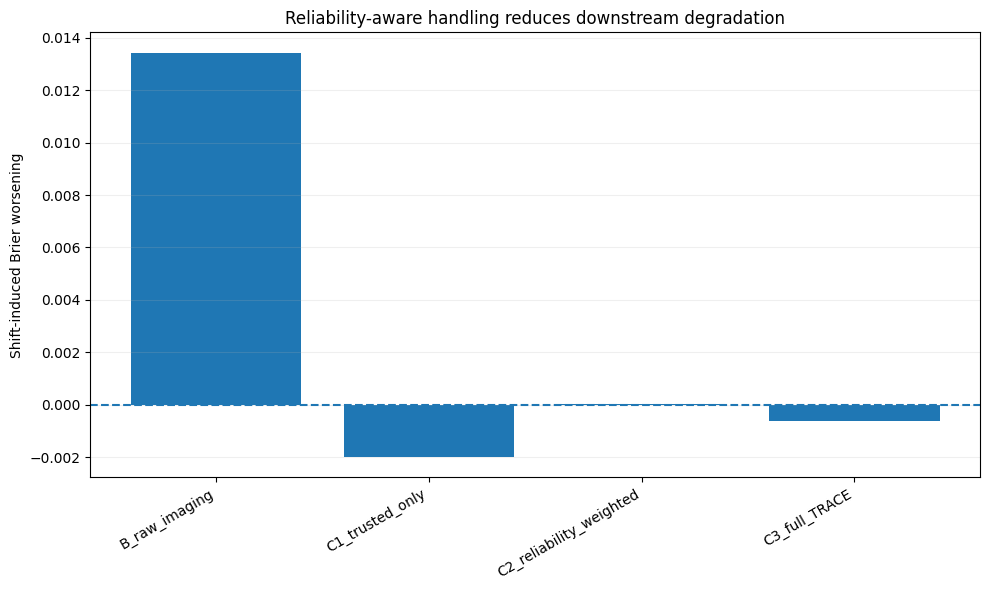

In [18]:

# ============================================================
# 16. ROBUSTNESS SUMMARY FIGURE
# ============================================================

compare_models = [
    "B_raw_imaging",
    "C1_trusted_only",
    "C2_reliability_weighted",
    "C3_full_TRACE"
]

plot = master.set_index("model").loc[
    compare_models
]

fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(len(compare_models))

ax.bar(
    x,
    plot["Brier_worsening"]
)

ax.axhline(0,linestyle="--")

ax.set_xticks(x)
ax.set_xticklabels(
    compare_models,
    rotation=30,
    ha="right"
)

ax.set_ylabel("Shift-induced Brier worsening")
ax.set_title("Reliability-aware handling reduces downstream degradation")
ax.grid(axis="y",alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIG_DIR/"trace_shift_robustness_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 17. Publication figure — patient-level raw B vs C3 probability shift


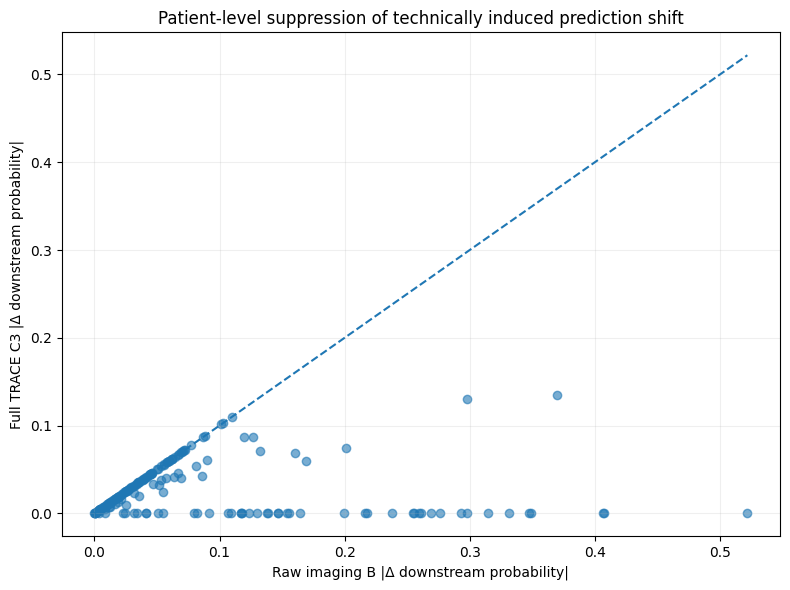

In [19]:

# ============================================================
# 17. B VS C3 PATIENT SHIFT
# ============================================================

b = np.abs(
    pred["B_raw_imaging_shifted"]
    - pred["B_raw_imaging_clean"]
)

c3 = np.abs(
    pred["C3_full_TRACE_shifted"]
    - pred["C3_full_TRACE_clean"]
)

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(
    b,
    c3,
    alpha=0.6
)

limit = max(b.max(),c3.max())

ax.plot(
    [0,limit],
    [0,limit],
    linestyle="--"
)

ax.set_xlabel("Raw imaging B |Δ downstream probability|")
ax.set_ylabel("Full TRACE C3 |Δ downstream probability|")
ax.set_title("Patient-level suppression of technically induced prediction shift")
ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIG_DIR/"raw_B_vs_C3_patient_shift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 18. Export all publication-ready outputs


In [20]:

# ============================================================
# 18. EXPORT
# ============================================================

master.to_csv(
    OUT_DIR/"table_primary_clean_shift_metrics.csv",
    index=False
)

primary_table.to_csv(
    OUT_DIR/"table_primary_manuscript.csv",
    index=False
)

consequence_table.to_csv(
    OUT_DIR/"table_trace_reliability_consequences.csv",
    index=False
)

bootstrap_ci.to_csv(
    OUT_DIR/"table_paired_bootstrap_ci.csv",
    index=False
)

if len(state_table):
    state_table.to_csv(
        OUT_DIR/"table_trace_state_subgroups.csv",
        index=False
    )

if len(subgroup_table):
    subgroup_table.to_csv(
        OUT_DIR/"table_site_scanner_subgroups.csv",
        index=False
    )

if len(false_change_table):
    false_change_table.to_csv(
        OUT_DIR/"table_false_change_consequence.csv",
        index=False
    )

boot.to_parquet(
    OUT_DIR/"paired_bootstrap_full.parquet",
    index=False
)

print("Saved Notebook 22 outputs to:", OUT_DIR)


Saved Notebook 22 outputs to: /content/neurofhir_trace/outputs_22



# 19. ICHI-ready interpretation summary

The manuscript should tell the results in this order:

### 1. Imaging adds information under clean conditions
Compare A vs B clean.

### 2. Raw imaging AI becomes less reliable under technical shift
Compare B clean vs B shifted.

### 3. TRACE reduces downstream instability
Compare B shifted vs C1/C2/C3 using:

- Brier score;
- calibration;
- ranking stability;
- probability-shift magnitude;
- false-change consequence.

### 4. Component handling strategies differ
Compare C1, C2, and C3.

### 5. Reliability benefit may be stronger than discrimination benefit
If AUROC confidence intervals overlap but calibration/stability improves, report exactly that.

### Do not claim
- clinical safety;
- diagnostic superiority;
- patient-outcome benefit;
- biological truth.

unless those are separately validated.


In [21]:

# ============================================================
# 19. SUMMARY
# ============================================================

m = master.set_index("model")

summary = {
    "DEMO_MODE": bool(DEMO_MODE),

    "B_clean_AUROC": float(
        m.loc["B_raw_imaging","clean_AUROC"]
    ),

    "B_shifted_AUROC": float(
        m.loc["B_raw_imaging","shifted_AUROC"]
    ),

    "B_shifted_Brier": float(
        m.loc["B_raw_imaging","shifted_Brier"]
    ),

    "C1_shifted_Brier": float(
        m.loc["C1_trusted_only","shifted_Brier"]
    ),

    "C2_shifted_Brier": float(
        m.loc["C2_reliability_weighted","shifted_Brier"]
    ),

    "C3_shifted_Brier": float(
        m.loc["C3_full_TRACE","shifted_Brier"]
    ),

    "B_rank_Spearman": float(
        m.loc["B_raw_imaging","Spearman_clean_vs_shift"]
    ),

    "C3_rank_Spearman": float(
        m.loc["C3_full_TRACE","Spearman_clean_vs_shift"]
    ),

    "B_top20_consistency": float(
        m.loc["B_raw_imaging","Top20pct_consistency"]
    ),

    "C3_top20_consistency": float(
        m.loc["C3_full_TRACE","Top20pct_consistency"]
    )
}

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["metric","value"]
)

display(summary_df)

summary_df.to_csv(
    OUT_DIR/"ichi_trace_22_summary.csv",
    index=False
)


,metric,value
0,DEMO_MODE,True
1,B_clean_AUROC,0.753937
2,B_shifted_AUROC,0.735373
3,B_shifted_Brier,0.2126
4,C1_shifted_Brier,0.194155
5,C2_shifted_Brier,0.197908
6,C3_shifted_Brier,0.196739
7,B_rank_Spearman,0.87433
8,C3_rank_Spearman,0.985043
9,B_top20_consistency,0.75



# 20. Decision gate for Notebook 23

Proceed to Notebook 23 when the following are complete:

1. primary A/B/C results are frozen;
2. paired bootstrap confidence intervals are available;
3. calibration plots are available;
4. false-change / prediction-shift analysis is complete;
5. subgroup analysis has been checked for major anomalies;
6. claims are aligned with the observed reliability endpoints.

---

# Next Notebook — 23

## FHIR Validation + Integrated ICHI Figures/Tables/Reproducibility Package

Notebook 23 should:

- load frozen results from 19B, 20B, 21, and 22;
- generate the final Figure 1–4 set;
- generate one TRUSTED and one REVIEW_REQUIRED FHIR evidence trace;
- validate structural FHIR fields;
- build the final manuscript table package;
- generate a reproducibility manifest;
- export a concise methods/results summary for writing the ICHI paper.

Notebook 23 is the final integration notebook before manuscript drafting.
